# Notebook 12 – Feature Relationships


In [7]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 823.4 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/8.2 MB 823.4 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.2 MB 965.3 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.2 MB 1.0 MB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.2 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.2 MB 986.6 kB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.2 MB 986.6 kB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 983.0 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.2 MB 957.0 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.2 MB 957.0 kB/s eta 0:00:07
   ----------- --

## Correlation Matrix

### Definition

A correlation matrix shows the correlation between every pair of numerical features in a dataset.

Correlation usually ranges from -1 to +1:

- +1 → Strong positive relationship
- 0 → No linear relationship
- -1 → Strong negative relationship

Example

Suppose we have:

| Age | Experience | Salary |
| --: | ---------: | -----: |
|  22 |          1 | 30,000 |
|  25 |          3 | 40,000 |
|  30 |          7 | 60,000 |
|  35 |         10 | 80,000 |


Age and Experience may have a positive correlation.

### Why do we use it?

**Correlation helps us:**

- Understand relationships between features.
- Find features that are strongly related.
- Detect possible multicollinearity.
- Understand which numerical variables may be related to the target.

### Python Example


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Age": [22, 25, 30, 35, 40],
    "Experience": [1, 3, 7, 10, 15],
    "Salary": [30000, 40000, 60000, 80000, 100000]
}

df = pd.DataFrame(data)

correlation = df.corr()

print(correlation)

                 Age  Experience    Salary
Age         1.000000    0.996827  0.999714
Experience  0.996827    1.000000  0.997187
Salary      0.999714    0.997187  1.000000


#### Heatmap

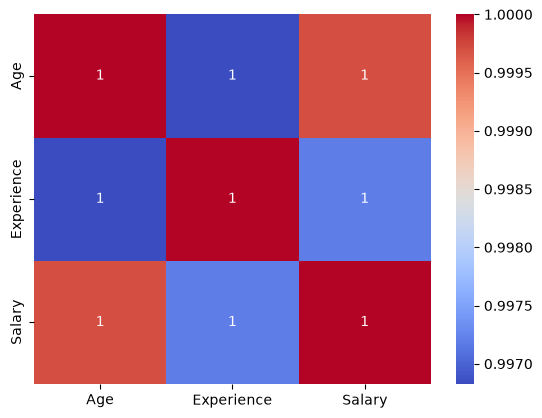

In [2]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Multicollinearity

### Definition

Multicollinearity occurs when two or more independent features are highly related to each other.

**For example:**

Age ────────────── Experience
       Strong relationship

If Age and Experience contain almost the same information, a model may have difficulty determining how much each feature independently contributes.

**Example**

Consider:

Age

Experience

Years_in_company

These variables may be strongly related.

For example, older employees may generally have more experience.

**Why is it a problem?**

Multicollinearity can:

- Make regression coefficients unstable.
- Make coefficient interpretation difficult.
- Increase the variance of coefficient estimates.
- Make it difficult to determine the individual effect of a feature.

**How to detect it?**

Two common approaches:

- Correlation Matrix
- VIF (Variance Inflation Factor)
### Python Example

In [3]:
correlation = df.corr()

print(correlation)

                 Age  Experience    Salary
Age         1.000000    0.996827  0.999714
Experience  0.996827    1.000000  0.997187
Salary      0.999714    0.997187  1.000000


Look for pairs of independent features with very high absolute correlation.


## Variance Inflation Factor (VIF)

### Definition

VIF measures how much the variance of a regression coefficient is inflated because of relationships between predictor variables.

The formula is:

$$ VIF = \frac{1}{1-R^2} $$

where R² is obtained by predicting one feature using the other features.

Simple interpretation

|    VIF | Common interpretation    |
| -----: | ------------------------ |
|    `1` | No multicollinearity     |
|  `1–5` | Usually acceptable       |
| `5–10` | Potentially high         |
|  `>10` | Often considered serious |

These are rules of thumb, not strict universal cutoffs.

**Why do we use VIF?**

Correlation only looks at the relationship between two variables.

VIF can identify whether a feature is highly predictable from multiple other features.

**Python Example**

In [4]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["Age", "Experience"]]

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

      Feature         VIF
0         Age  157.813523
1  Experience  157.813523


## Feature Importance

### Definition

Feature importance tells us how useful different features are for making predictions in a machine-learning model.

**Why do we use it?**

Feature importance helps us:

- Understand the model.
- Identify useful features.
- Remove potentially unnecessary features.
- Explain which variables contribute to model predictions.

### Example using Random Forest

In [8]:
from sklearn.ensemble import RandomForestRegressor

X = df[["Age", "Experience"]]
y = df["Salary"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print(importance)

Age           0.502623
Experience    0.497377
dtype: float64


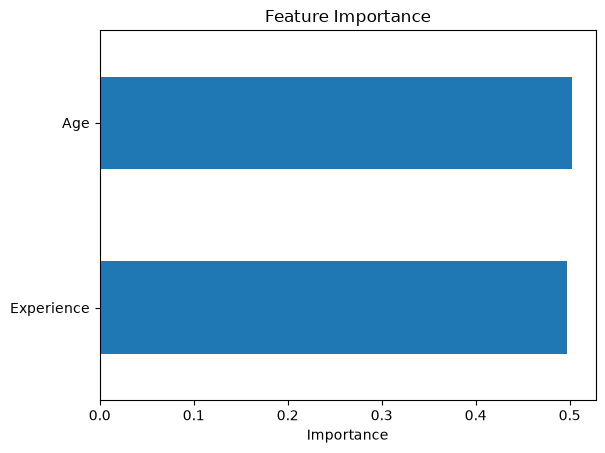

In [9]:
importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

The model used Experience more heavily than Age according to this particular importance measure.

`Important:` Feature importance is model-dependent. A high importance value does not automatically mean the feature causes the target to change.

## Feature Selection Basics

### Definition

Feature selection means choosing the most useful features for a machine-learning model and removing features that are unnecessary, redundant, or potentially harmful.

**For example:**

Original Features

- Age
- Experience
- Salary
- City
- Customer_ID
- Phone_Number

After feature selection:

Useful Features

- Age
- Experience
- City

**Why do we use it?**

Feature selection can:

- Reduce model complexity.
- Reduce training time.
- Remove redundant information.
- Reduce overfitting in some situations.
- Make models easier to interpret.

### Types of Feature Selection

#### 1. Filter Methods

Features are selected using statistical properties before training a model.

Examples:

- Correlation
- Chi-Square
- ANOVA
- Mutual Information

#### Example:

In [10]:
correlation = df.corr()

print(correlation["Salary"].sort_values())

Experience    0.997187
Age           0.999714
Salary        1.000000
Name: Salary, dtype: float64


## Wrapper Methods

Wrapper methods evaluate different combinations of features by actually training a model.

### Examples:

- Forward Selection
- Backward Elimination
- Recursive Feature Elimination (RFE)

### Python Example – RFE

In [11]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = df[["Age", "Experience"]]
y = df["Salary"]

model = LinearRegression()

rfe = RFE(
    estimator=model,
    n_features_to_select=1
)

rfe.fit(X, y)

print("Selected features:")
print(X.columns[rfe.support_])

Selected features:
Index(['Age'], dtype='str')


### Embedded Methods

Feature selection happens during model training.

**Examples:**

- Lasso Regression
- Decision Trees
- Random Forest
- Gradient Boosting

For example, Lasso can shrink some coefficients to zero:



In [12]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)

model.fit(X, y)

print(model.coef_)

[3524.59822829  520.03067371]


A coefficient of 0 means that Lasso has effectively excluded that feature from the linear model.

### Correlation vs Multicollinearity vs VIF vs Feature Importance

| Concept                | What does it tell us?                                 |
| ---------------------- | ----------------------------------------------------- |
| **Correlation**        | Relationship between two variables                    |
| **Correlation Matrix** | Relationships between many pairs of variables         |
| **Multicollinearity**  | Predictors are strongly related to each other         |
| **VIF**                | How much a predictor is explained by other predictors |
| **Feature Importance** | How useful a feature is to a particular model         |
| **Feature Selection**  | Which features we decide to keep                      |
